## 1 - Model 2 Random Forest

Based on evidence from recent studies, tree-based ensemble models such as  Random Forest seem the most suitable choice for intrusion detection using the NSL-KDD dataset. RF consistently achieved accuracy above 99% across multiple experiments (Abrar et al., 2020; Hegde et al., 2024; Hong et al., 2021; Gawand & Meesala, 2025). It effectively handles the dataset’s mixed-type features and class imbalance, while providing high interpretability and resilience to overfitting. Compared to deep learning models, RF offers an optimal trade-off between performance, computational efficiency and ease of implementation. This makes it a very appropriate algorithm for both academic experimentation and practical network intrusion detection.

Main goal is to:
* Identify the most informative NSL-KDD features
* Improve multi-class prediction performance over logistic regression
* Build a more expressive model without overfitting
* Evaluate Model 3, generate interpretable insights to produce a final, optimized RF model ready for test evaluation

Furthermore, in Model 3, the RF algorithm is intentionally used twice, but for two different purposes. First, an initial RF is trained on the full feature set to compute feature importances. This model is not used for prediction, it is only used to rank the NSL-KDD attributes and identify which features carry meaningful signal versus which ones introduce noise or redundancy. Based on this ranking, a reduced subset of the most informative features is selected. In the second stage, a new RF model is trained and only on the selected features, to serve as the actual predictive classifier. This separation ensures that the final model benefits from a cleaner and lower-dimensional feature space and enables an assessment of how feature selection influences model performance.



In [22]:
# Start by importing all required libs...
import os
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from pathlib import Path
from utils import load_split, FEATURE_COLUMNS
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay, confusion_matrix
import warnings
from sklearn.exceptions import UndefinedMetricWarning
import matplotlib.pyplot as plt
import joblib

In [ ]:
# Part one: selecting the most importan features
DATA_DIR   = Path("data/processed")
MODELS_DIR = Path("models")
MODELS_DIR.mkdir(parents=True, exist_ok=True)

X_train, y_train = load_split("train", DATA_DIR)
X_val,   y_val   = load_split("val", DATA_DIR)
X_test,  y_test  = load_split("test", DATA_DIR)

print("The shapes:")
print("  X_train:", X_train.shape)
print("  X_val:  ", X_val.shape)
print("  X_test: ", X_test.shape)

assert X_train.shape[1] == len(FEATURE_COLUMNS), "Feature dimension issue..."


# RF used only for ranking features
rf_feat_imp = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample", # minority classes are not ignored
)
rf_feat_imp.fit(X_train, y_train)

importances = rf_feat_imp.feature_importances_

feat_imp_df = (
    pd.DataFrame({"feature": FEATURE_COLUMNS, "importance": importances})
    .sort_values("importance", ascending=False)
)

print("\nTop 10 features by RF importance:")
print(feat_imp_df.head(10))

TOP_F = 20 # 50% dimensionality reduction
top_features = feat_imp_df.head(TOP_F)["feature"].tolist()
print(f"\nSelected top-{TOP_F} features:\n", top_features)

# create index mapping
name_to_idx = {name: idx for idx, name in enumerate(FEATURE_COLUMNS)}
selected_idx = [name_to_idx[f] for f in top_features]

X_train_sel = X_train[:, selected_idx]
X_val_sel   = X_val[:,   selected_idx]
X_test_sel  = X_test[:,  selected_idx]

print("\n The Shapes after feature selection:")
print("  X_train_sel:", X_train_sel.shape)
print("  X_val_sel:  ", X_val_sel.shape)
print("  X_test_sel: ", X_test_sel.shape)

The shapes:
  X_train: (100778, 41)
  X_val:   (25195, 41)
  X_test:  (22544, 41)

Top 10 features by RF importance:
                        feature  importance
4                     src_bytes    0.097232
5                     dst_bytes    0.064228
2                       service    0.052866
32           dst_host_srv_count    0.048483
31               dst_host_count    0.047082
7                wrong_fragment    0.046191
36  dst_host_srv_diff_host_rate    0.043701
35  dst_host_same_src_port_rate    0.037076
23                    srv_count    0.033839
0                      duration    0.032905

Selected top-20 features:
 ['src_bytes', 'dst_bytes', 'service', 'dst_host_srv_count', 'dst_host_count', 'wrong_fragment', 'dst_host_srv_diff_host_rate', 'dst_host_same_src_port_rate', 'srv_count', 'duration', 'dst_host_diff_srv_rate', 'dst_host_same_srv_rate', 'count', 'protocol_type', 'dst_host_srv_serror_rate', 'dst_host_serror_rate', 'hot', 'land', 'flag', 'logged_in']

 The Shapes after fea

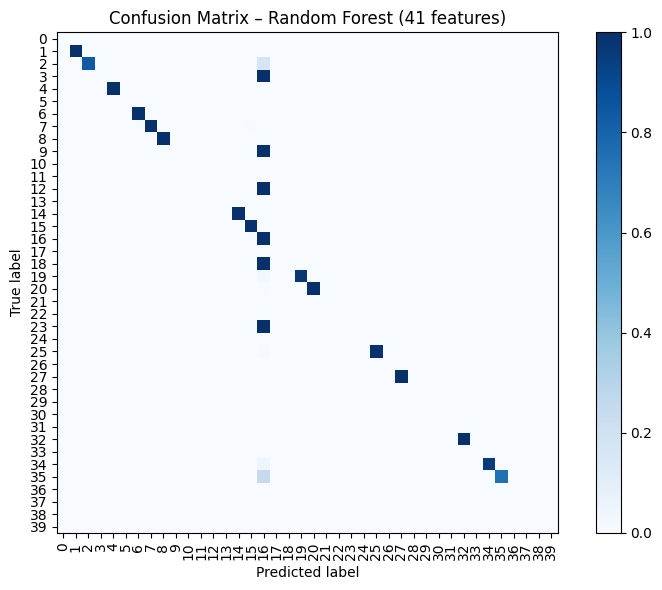

Random Forest: all features
              precision    recall  f1-score   support

           1     0.9948    1.0000    0.9974       191
           2     1.0000    0.8333    0.9091         6
           3     0.0000    0.0000    0.0000         2
           4     1.0000    1.0000    1.0000        11
           6     1.0000    1.0000    1.0000         2
           7     0.9986    0.9931    0.9958       720
           8     0.8000    1.0000    0.8889         4
           9     0.0000    0.0000    0.0000         2
          12     0.0000    0.0000    0.0000         1
          14     1.0000    1.0000    1.0000      8243
          15     0.9835    0.9967    0.9900       299
          16     0.9978    0.9996    0.9987     13469
          18     0.0000    0.0000    0.0000         1
          19     1.0000    0.9750    0.9873        40
          20     1.0000    0.9932    0.9966       586
          23     0.0000    0.0000    0.0000         2
          25     0.9986    0.9904    0.9945       727

In [ ]:
# Create a baseline RF
rf_full = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

rf_full.fit(X_train, y_train)


# Load class labels from the encoder (created in data prep)
y_encoder = joblib.load("data/processed/label_encoder.joblib")
class_labels = list(range(len(y_encoder.classes_)))   # numeric labels

y_val_pred_full = rf_full.predict(X_val)

# Confusion matrix
cm_full = confusion_matrix(y_val, y_val_pred_full, labels=class_labels, normalize='true')

classes = np.arange(cm_full.shape[0])

plt.figure(figsize=(8, 6))
plt.imshow(cm_full, interpolation='nearest', cmap="Blues")
plt.title("Confusion Matrix – Random Forest (41 features)")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()



warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

print("Random Forest: all features")
print(classification_report(y_val, y_val_pred_full, digits=4)) # use 4 digits for more precise comparison?
print("Accuracy:", accuracy_score(y_val, y_val_pred_full))

# Evaluate full-feature model on the test set
y_test_pred_full = rf_full.predict(X_test)

print("Random Forest: all features (test set)")
print(classification_report(y_test, y_test_pred_full, digits=4))
print("Accuracy:", accuracy_score(y_test, y_test_pred_full))


During evaluation, scikit-learn generated ‘UndefinedMetricWarning’ for U2R and R2L classes. This occurs when the model predicts zero samples for a class, causing precision or F1-score to be undefined. This is typical for the NSL-KDD dataset, where some classes are extremely underrepresented.

The classification report for the RF models reveals that several classes have extremely low support (e.g., only 1–10 samples) or do not appear at all in the validation set. This behavior is entirely expected for the NSL-KDD dataset, which contains 41 granular attack subtypes that are highly imbalanced. While major classes such as normal, DoS, and Probe contain thousands of samples, rare subtypes (e.g. R2L and U2R categories) only occur a handful of times or sometimes not at all within a given split. As a result, scikit-learn reports zero precision, recall, and F1-score for classes that the model never predicts or that never appear in the evaluation subset. For example, labels such as 5, 10, 11, and others do not appear in the validation confusion matrix simply because no instances of these subtypes are present in the validation data, the model cannot be evaluated on classes it does not see. This extreme imbalance also explains why the macro-averaged F1-score is substantially lower than the weighted F1-score: macro-averaging assigns equal weight to all classes, causing very rare classes with zero performance to pull the average downward. In contrast, the weighted average remains high because the dominant classes, which the model handles extremely well, account for the majority of samples. In summary, these observations reflect structural properties of the NSL-KDD dataset rather than deficiencies in the model.

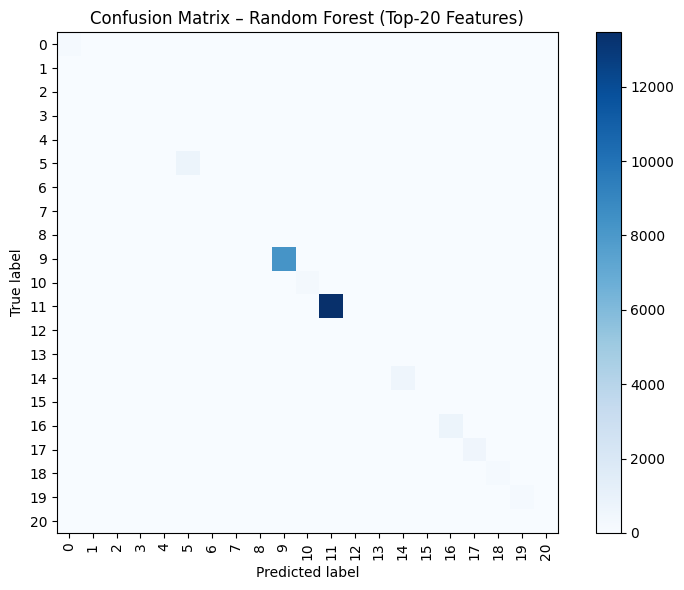

Random Forest: top 20 features
              precision    recall  f1-score   support

           1     0.9948    1.0000    0.9974       191
           2     1.0000    0.6667    0.8000         6
           3     0.0000    0.0000    0.0000         2
           4     1.0000    1.0000    1.0000        11
           6     1.0000    1.0000    1.0000         2
           7     0.9986    0.9944    0.9965       720
           8     0.8000    1.0000    0.8889         4
           9     0.0000    0.0000    0.0000         2
          12     0.0000    0.0000    0.0000         1
          14     1.0000    1.0000    1.0000      8243
          15     0.9868    0.9967    0.9917       299
          16     0.9975    0.9996    0.9985     13469
          18     0.0000    0.0000    0.0000         1
          19     1.0000    0.9750    0.9873        40
          20     1.0000    0.9932    0.9966       586
          23     0.0000    0.0000    0.0000         2
          25     0.9986    0.9890    0.9938       

In [25]:
# RF with feature selection
rf_feat = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample",
)

rf_feat.fit(X_train_sel, y_train)

warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

y_val_pred_sel = rf_feat.predict(X_val_sel)

# Confusion matrix
cm_sel = confusion_matrix(y_val, y_val_pred_sel)
classes = np.arange(cm_sel.shape[0])

plt.figure(figsize=(8, 6))
plt.imshow(cm_sel, interpolation='nearest', cmap="Blues")
plt.title("Confusion Matrix – Random Forest (Top 20 Features)")
plt.colorbar()
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=90)
plt.yticks(tick_marks, classes)
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.tight_layout()
plt.show()


print("Random Forest: top 20 features")
print(classification_report(y_val, y_val_pred_sel, digits=4))
print("Accuracy:", accuracy_score(y_val, y_val_pred_sel))

# Evaluate selected-feature model on the test set
y_test_pred_sel = rf_feat.predict(X_test_sel)

print("Random Forest: top 20 features (test set)")
print(classification_report(y_test, y_test_pred_sel, digits=4))
print("Accuracy:", accuracy_score(y_test, y_test_pred_sel))

Both Random Forest models—one trained on all 41 NSL-KDD features and one trained on the top-20 features selected using RF-based importance—achieve almost identical performance. On the validation set, the full-feature model performs slightly better in terms of macro-F1 (0.742 vs. 0.732), while accuracy and weighted F1-scores are nearly identical. When evaluated on the test set, both models experience a substantial and expected performance drop, achieving 0.72 accuracy and low macro-F1. This decrease is a known characteristic of NSL-KDD because the test set was intentionally designed by Tavallaee et al. (2009) to include attack subtypes that do not appear in the training data, making generalization more challenging. Macro-F1 is further penalized by the extreme class imbalance of the dataset, as several attack subtypes appear only a handful of times and are treated as equally important as the dominant classes. 

To further examine model behavior, confusion matrices were generated for both the full-feature and selected-feature Random Forests. The confusion matrices confirm the quantitative evaluation: both Random Forest models exhibit almost identical behavior. For both models, the diagonal elements corresponding to the major classes (e.g., normal, DoS, and Probe subtypes) remain very strong, which demonstrates that RF can reliably classify the large, majority classes. However, both confusion matrices also reveal a consistent failure to detect rare attack subtypes such as R2L and U2R. In general, the full-feature model remains marginally stronger, indicating that RF already handle redundant or weak features effectively. Feature selection therefore does not provide a measurable performance gain in this setting, although it also does not significantly harm performance. These findings confirm that Random Forests are inherently robust to high-dimensional input and dimensionality reduction is optional rather than necessary for the NSL-KDD dataset.

However, research suggests...




In the Logistic Regression baseline, we evaluated both the binary and multi-class versions of the NSL-KDD task. This dual setup already revealed a clear pattern: Logistic Regression performs extremely well in the binary normal-vs-attack setting, but struggles in the multi-class scenario due to the heavy skew of rare attack subtypes. The Random Forest model shows the same behavior—strong performance on the major classes but significant difficulties on the long tail of infrequent attack types, as reflected in the multi-class macro-F1 and confusion matrices. To enable a direct comparison with the LR baseline and to isolate the true detection ability of the RF model, we therefore extend the analysis by adding a binary classification experiment. This reduces the problem to the fundamental IDS question: is the traffic benign or malicious? The binary RF results serve as an upper-bound estimate of detection performance and help clarify whether the multi-class limitations arise from model complexity or from structural issues within the dataset.  Furthermore, RF was not evaluated using ROC, AUC, or k-fold cross-validation. In the binary setting, RF already achieves near-perfect accuracy and F1-scores, so ROC/AUC curves would offer no additional insight beyond confirming the same result.

In [29]:
# Extract normal class and convert to binary labels
classes = y_encoder.classes_
normal_id = np.where(classes == "normal")[0][0]
print("Normal class: ", normal_id)

y_train_bin = (y_train != normal_id).astype(int)
y_val_bin   = (y_val   != normal_id).astype(int)
y_test_bin  = (y_test  != normal_id).astype(int)

# train and evaluate the binary model
warnings.filterwarnings("ignore", category=UndefinedMetricWarning)

rf_bin = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_bin.fit(X_train, y_train_bin)

y_val_bin_pred = rf_bin.predict(X_val)
print("Binary RF (Validation)")
print(classification_report(y_val_bin, y_val_bin_pred, digits=4))
print("Accuracy:", accuracy_score(y_val_bin, y_val_bin_pred))

y_test_bin_pred = rf_bin.predict(X_test)
print("Binary RF (test)")
print(classification_report(y_test_bin, y_test_bin_pred, digits=4))
print("Accuracy:", accuracy_score(y_test_bin, y_test_bin_pred))


Normal class:  16
Binary RF (Validation)
              precision    recall  f1-score   support

           0     0.9983    0.9996    0.9990     13469
           1     0.9996    0.9980    0.9988     11726

    accuracy                         0.9989     25195
   macro avg     0.9989    0.9988    0.9989     25195
weighted avg     0.9989    0.9989    0.9989     25195

Accuracy: 0.9988886683865846
Binary RF (test)
              precision    recall  f1-score   support

           0     0.6556    0.9719    0.7830      9711
           1     0.9665    0.6137    0.7507     12833

    accuracy                         0.7680     22544
   macro avg     0.8111    0.7928    0.7669     22544
weighted avg     0.8326    0.7680    0.7647     22544

Accuracy: 0.7680092264017033


The binary classification experiment provides more insight on the RF true detection capability. On the validation set, the binary RF model achieves near-perfect performance (accuracy ≈ 0.999, F1 ≈ 0.999 for both classes). This demonstrates that, when the task is simplified to distinguishing benign vs. malicious traffic, the model performs exceptionally well and has no difficulty detecting attack activity in general. However, the behavior on the test set reveals an important aspect of the NSL-KDD benchmark. Although the binary accuracy remains substantial (≈ 0.768), the model shows a pronounced asymmetry between the two classes:
* Normal traffic: High recall (0.9719), but relatively low precision (0.6556) which means many malicious samples are misclassified as normal (false negatives)
* Attack traffic: Very high precision (0.9665), but low recall (0.6137) which means many malicious samples are missed rather than incorrectly predicted.

This pattern indicates that the model becomes more conservative on unseen test data: it makes very few false attack predictions (high precision), but it fails to correctly identify a substantial fraction of test-set attacks (lower recall). This is consistent with the design of NSL-KDD: the test set contains many attack types not present during training, and some appear only a few times. As a result, even the binary classifier struggles to generalize to completely unseen malicious behavior. Hence, the main difficulty in NSL-KDD is not detecting whether a sample is malicious, but generalizing to rare or unseen attack patterns. This also explains why the multi-class performance was low. The model never learns enough examples of the rare subtypes to classify them reliably. Even in the binary setting, where the task is easier, these limitations remain visible once the model is evaluated on the more challenging test split.